In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme()
df = sns.load_dataset("penguins")
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [3]:
import sklearn
print(sklearn.__version__)

1.7.2


In [4]:
from sklearn.model_selection import train_test_split
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
# WE USE MultiOutputRegressor WHEN WE HAVE MORE THAN ONE TARGETED COLUMN
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

In [5]:
df=pd.read_csv('fund_allocation_dataset.csv')
df

,Income,Age,Risk_Appetite,Net_Worth,Investment_Horizon,Stock_Allocation,Bond_Allocation,FD_Allocation,ETF_Allocation,Cash_Allocation,Other_Allocation,Expected_Return,Portfolio_Volatility
0,89274.50,43,High,897187.11,18,66.14,8.77,5.47,17.74,1.69,0.19,10.00,15.77
1,53717.19,30,High,542263.50,30,66.61,6.30,3.24,9.53,0.71,13.60,10.86,15.75
2,100735.21,48,Medium,311162.99,19,36.73,17.18,13.13,18.82,14.07,0.07,7.06,11.83
3,202911.20,32,Medium,815671.24,30,39.82,26.45,9.67,13.20,8.68,2.18,7.81,13.90
4,49750.57,48,Medium,404659.56,18,30.49,23.20,6.90,17.05,9.56,12.80,7.19,12.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,131934.38,27,Low,1171742.65,30,11.30,29.81,14.52,8.12,30.36,5.89,4.29,9.70
17996,32062.83,34,Medium,268191.03,30,33.22,26.30,6.91,10.20,10.71,12.65,5.45,11.51
17997,112454.52,44,Medium,575636.94,14,31.63,24.75,11.46,11.17,9.20,11.79,6.69,13.58
17998,23924.45,50,Low,109529.48,14,17.85,30.84,19.65,6.72,16.97,7.97,4.90,9.75


In [6]:
df.isnull().sum()

Income                  0
Age                     0
Risk_Appetite           0
Net_Worth               0
Investment_Horizon      0
Stock_Allocation        0
Bond_Allocation         0
FD_Allocation           0
ETF_Allocation          0
Cash_Allocation         0
Other_Allocation        0
Expected_Return         0
Portfolio_Volatility    0
dtype: int64

In [7]:
df = pd.read_csv('fund_allocation_dataset.csv')
df[['Stock_Allocation', 'Bond_Allocation', 'FD_Allocation', 'ETF_Allocation', 'Cash_Allocation', 'Other_Allocation']].describe()


,Stock_Allocation,Bond_Allocation,FD_Allocation,ETF_Allocation,Cash_Allocation,Other_Allocation
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,31.299816,22.803006,13.745099,11.520147,14.065503,6.566403
std,17.393393,10.017097,7.667790,4.207715,7.365908,4.062734
min,4.570000,0.010000,0.000000,3.990000,0.000000,0.000000
25%,16.190000,16.180000,7.997500,7.900000,8.310000,3.240000
50%,32.910000,23.805000,12.600000,11.040000,12.600000,6.340000
75%,41.730000,30.220000,19.800000,14.900000,19.760000,9.340000
max,82.390000,49.150000,36.080000,25.950000,37.740000,22.810000


In [8]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Stock_Allocation','Bond_Allocation','FD_Allocation','ETF_Allocation','Cash_Allocation','Other_Allocation'],axis=1),
                                                 df[['Stock_Allocation', 'Bond_Allocation', 'FD_Allocation',
        'ETF_Allocation', 'Cash_Allocation', 'Other_Allocation']],
                                                 test_size=0.3,
                                                 random_state=0)

In [9]:
X_train

,Income,Age,Risk_Appetite,Net_Worth,Investment_Horizon,Expected_Return,Portfolio_Volatility
13698,27797.18,41,Medium,232482.60,26,7.62,12.92
8027,62945.47,56,Medium,447356.96,12,8.44,15.73
7358,23123.39,20,Medium,107813.17,30,7.93,15.65
11233,53471.27,24,Medium,133741.22,30,7.33,13.16
2016,48556.72,23,Medium,215978.71,30,6.87,11.26
...,...,...,...,...,...,...,...
9225,69341.35,41,Low,397864.97,25,3.86,9.22
13123,58826.15,55,Medium,259509.17,8,7.86,13.28
9845,49573.68,45,Low,481961.97,20,4.54,7.55
10799,159587.27,46,Medium,1375721.73,19,7.10,13.27


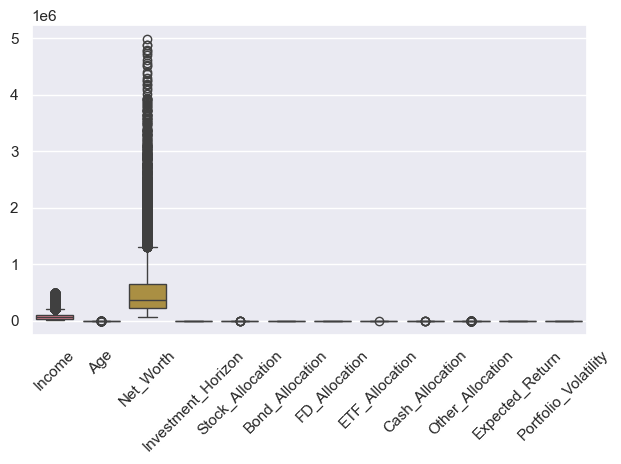

In [10]:
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
plt.tight_layout()       # Adjust layout to prevent cutting off labels
plt.show()

In [11]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Loop through columns and apply Shapiro-Wilk test
for col in numeric_cols:
    try:
        stat, p = shapiro(df[col].dropna())  # dropna() avoids errors from missing values
        print(f"Column: {col}")
        print(f"  Shapiro-Wilk stat = {stat:.3f}, p = {p:.3f}")
        if p > 0.05:
            print("  ✅ Likely normal (fail to reject H0)\n")
        else:
            print("  ❌ Not normal (reject H0)\n")
    except Exception as e:
        print(f"⚠️ Error testing {col}: {e}\n")


Column: Income
  Shapiro-Wilk stat = 0.753, p = 0.000
  ❌ Not normal (reject H0)

Column: Age
  Shapiro-Wilk stat = 0.989, p = 0.000
  ❌ Not normal (reject H0)

Column: Net_Worth
  Shapiro-Wilk stat = 0.722, p = 0.000
  ❌ Not normal (reject H0)

Column: Investment_Horizon
  Shapiro-Wilk stat = 0.842, p = 0.000
  ❌ Not normal (reject H0)

Column: Stock_Allocation
  Shapiro-Wilk stat = 0.945, p = 0.000
  ❌ Not normal (reject H0)

Column: Bond_Allocation
  Shapiro-Wilk stat = 0.981, p = 0.000
  ❌ Not normal (reject H0)

Column: FD_Allocation
  Shapiro-Wilk stat = 0.974, p = 0.000
  ❌ Not normal (reject H0)

Column: ETF_Allocation
  Shapiro-Wilk stat = 0.962, p = 0.000
  ❌ Not normal (reject H0)

Column: Cash_Allocation
  Shapiro-Wilk stat = 0.966, p = 0.000
  ❌ Not normal (reject H0)

Column: Other_Allocation
  Shapiro-Wilk stat = 0.973, p = 0.000
  ❌ Not normal (reject H0)

Column: Expected_Return
  Shapiro-Wilk stat = 0.967, p = 0.000
  ❌ Not normal (reject H0)

Column: Portfolio_Volati

C:\Users\Dell\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18000.
  res = hypotest_fun_out(*samples, **kwds)


C:\Users\Dell\AppData\Local\Temp\ipykernel_14396\3337626576.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])  # `sns.distplot` is deprecated


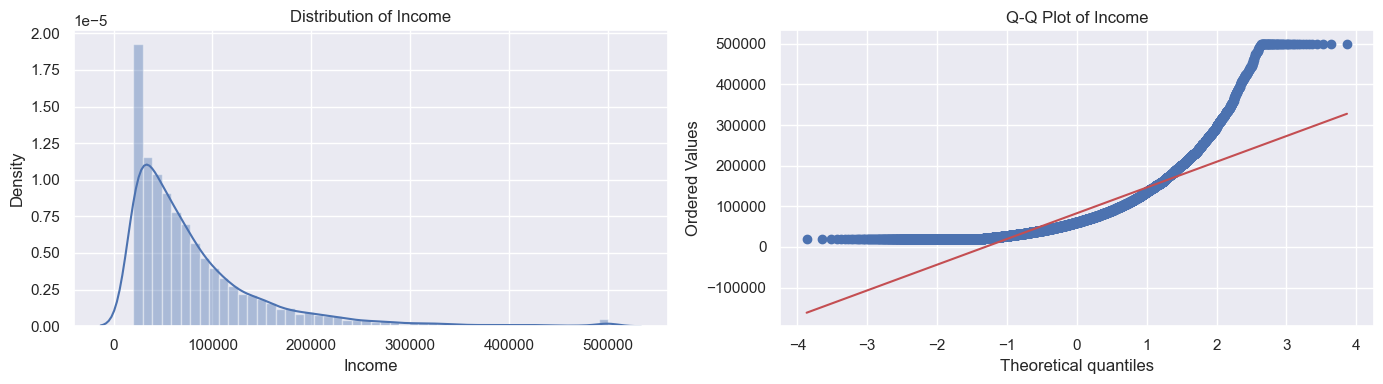

C:\Users\Dell\AppData\Local\Temp\ipykernel_14396\3337626576.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])  # `sns.distplot` is deprecated


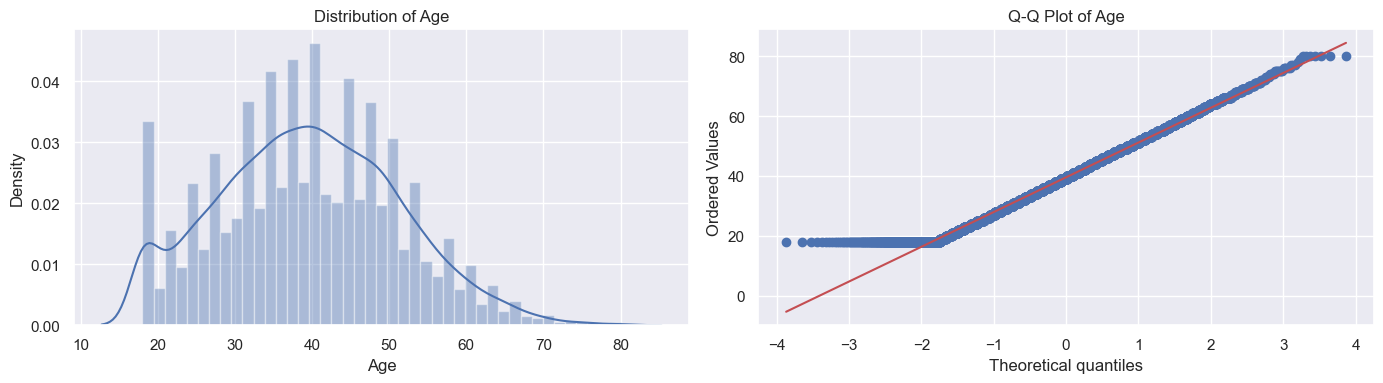

C:\Users\Dell\AppData\Local\Temp\ipykernel_14396\3337626576.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])  # `sns.distplot` is deprecated


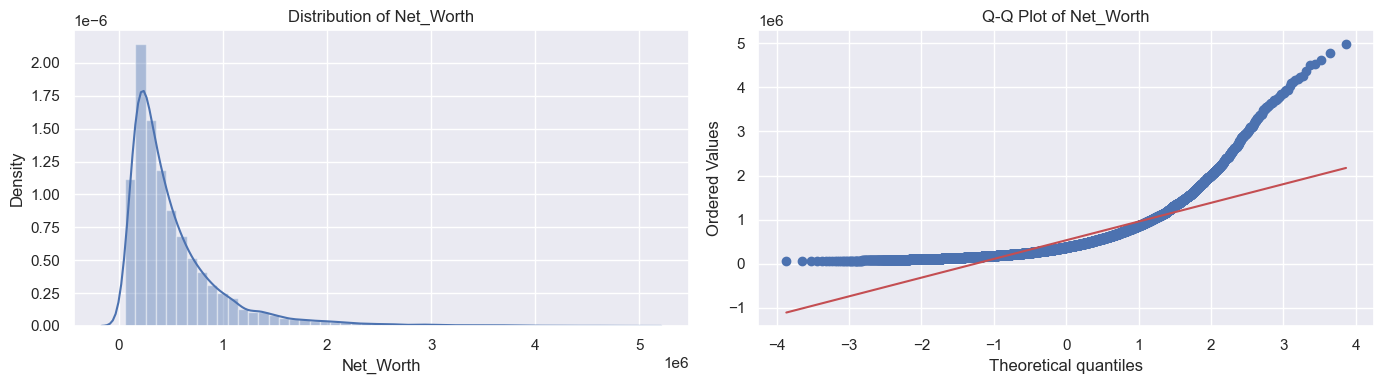

C:\Users\Dell\AppData\Local\Temp\ipykernel_14396\3337626576.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])  # `sns.distplot` is deprecated


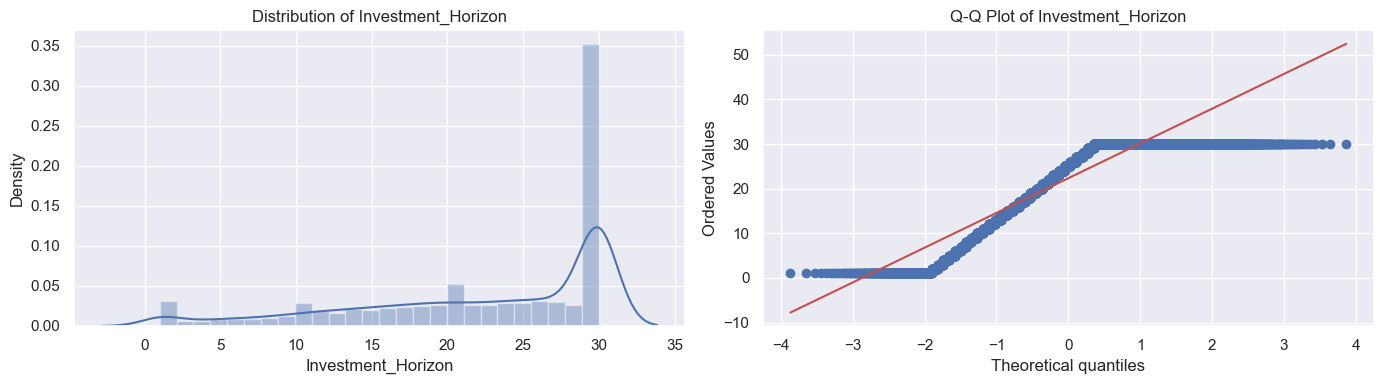

C:\Users\Dell\AppData\Local\Temp\ipykernel_14396\3337626576.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])  # `sns.distplot` is deprecated


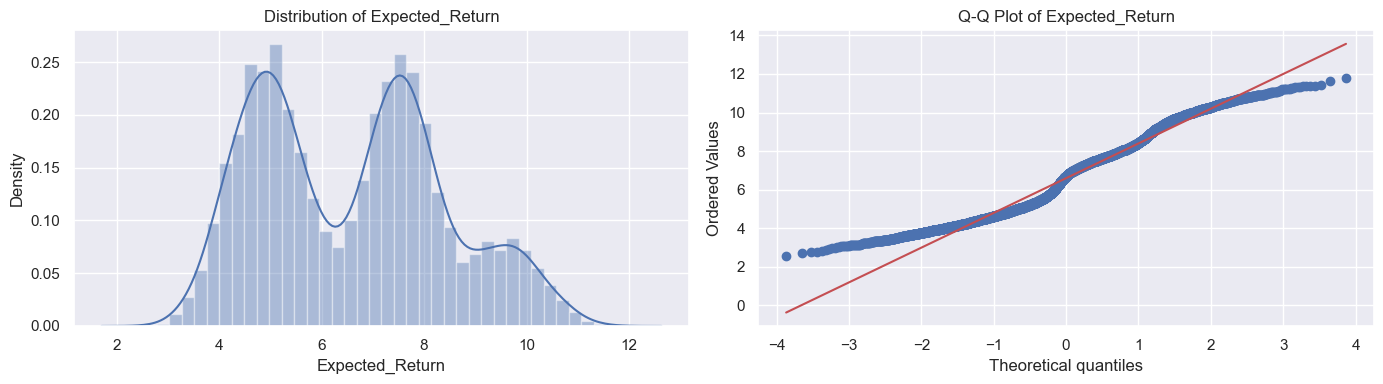

C:\Users\Dell\AppData\Local\Temp\ipykernel_14396\3337626576.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])  # `sns.distplot` is deprecated


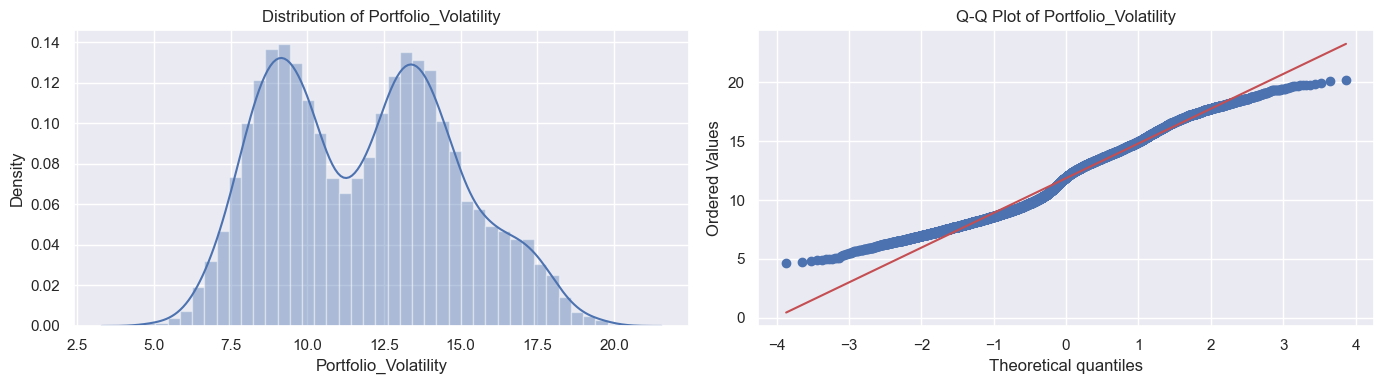

In [12]:
numeric_cols = X_train.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(14, 4))
    
    plt.subplot(121)
    sns.distplot(X_train[col])  # `sns.distplot` is deprecated
    plt.title(f'Distribution of {col}')
    
    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')
    
    plt.tight_layout()
    plt.show()


# AFTER APPLYING LOG TRANSFORM 
** INTERPRETATION **
- COLUMNS THAT GET BETTER:-INCOME,NET_WORTH,EXPECTED_RETURNS,PORTFOLIO_VOLATILITY
- COLUMNS THAT GET WORST:-AGE,INVESTMENT_HORIZON

In [13]:
print(type(X_train))
print(X_train.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
['Income', 'Age', 'Risk_Appetite', 'Net_Worth', 'Investment_Horizon', 'Expected_Return', 'Portfolio_Volatility']


# WE HAVE APPLIED YEO_JOHNSON(I HAVE DELETED THAT PART AFTER APPLYING) BUT STILL Investment_Horizon WAS NOT NORMALIZED 
** INTERPRETATION **
- WE WILL APPLY BINNING(QUANTILE) ON Investment_Horizon

In [14]:
log_cols = ['Income', 'Net_Worth', 'Expected_Return', 'Portfolio_Volatility']
binning = ['Investment_Horizon']
ordinal = ['Risk_Appetite']
scale_only = ['Age']

trf2 = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), log_cols),
    ('log_scale', StandardScaler(), log_cols),
    ('binning', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform'), binning),
    ('ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High']]), ordinal),
    ('scale', StandardScaler(), scale_only)
], remainder='passthrough') 

trf3=LinearRegression()

# AFTER APPLYING ALL THE ABOVE OPERATIONS IN TRF2 WE HAVE TO FIT AND TRANSFORM THEM
X_train_transformed2 = trf2.fit_transform(X_train)
X_train_transformed2 = pd.DataFrame(X_train_transformed2)

# IMP

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train_transformed2[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train_transformed2[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

## SELECTING BASE ML MODEL

In [15]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

### FIRSTLY I HAVE ADDED ALL THE MODELS INSIDE A SINGLE MODEL BUT DUE TO MANY REGRESSION MODELS IT TAKES A LOT OF TIME TO RUN.
### SO I CREATED DIFFERENT MODELS LIKE MODEL1,MODEL2,MODEL3 SO IT WILL TAKE LESS TIME TO RUN

In [16]:
models1 = {
    "LinearRegression":MultiOutputRegressor(LinearRegression()),
    "Ridge": MultiOutputRegressor(Ridge()),
    "Lasso": MultiOutputRegressor(Lasso())   
}


In [17]:
models2={
    "DecisionTree": MultiOutputRegressor(DecisionTreeRegressor()),
    "RandomForest": MultiOutputRegressor(RandomForestRegressor()),
    "KNN":MultiOutputRegressor(KNeighborsRegressor())
}


In [18]:
models3={
    "SVR": MultiOutputRegressor(SVR()),
    "ElasticNet": MultiOutputRegressor(ElasticNet())
}

## TESTING DIFFERENT REGRESSION MODEL AND CHECKING THE MSE 

In [19]:
mse_results = {}
for name, model in models1.items():
    pipe = Pipeline([
        ('trf2', trf2), 
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_results[name] = mse

print(mse_results)

{'LinearRegression': 14.56826300459882, 'Ridge': 14.573902213489736, 'Lasso': 17.38415576989683}


In [20]:
mse_results = {}
for name, model in models2.items():
    pipe = Pipeline([
        ('trf2', trf2),  
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_results[name] = mse

print(mse_results)

{'DecisionTree': 29.149851685185183, 'RandomForest': 15.171334432809877, 'KNN': 17.23311394222222}


In [21]:
mse_results = {}
for name, model in models3.items():
    pipe = Pipeline([
        ('trf2', trf2),  
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_results[name] = mse

print(mse_results)

{'SVR': 15.1186169734207, 'ElasticNet': 19.951809979088793}


**INTERPRETATION**
- AFTER TESTING ALL ABOVE ALgorithm THE BEST ONE IS LinearRegression

### CREATING THE FINAL MODEL

In [22]:
from sklearn import set_config
set_config(display='diagram')

In [24]:
final_model=Pipeline([
        ('trf2',trf2),
        ('best_model',MultiOutputRegressor(LinearRegression()))
])

In [25]:
final_model.fit(X_train,y_train)

,steps,"[('trf2', ...), ('best_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log', ...), ('log_scale', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred=final_model.predict(X_test)
y_pred

array([[12.74724942, 31.9514941 , 20.78906735,  7.84276598, 21.38341199,
         5.28609562],
       [41.80158412, 18.3954802 ,  9.73962837, 13.68055113,  9.24723122,
         7.13553972],
       [13.98745421, 31.937646  , 20.27511258,  8.08418637, 20.43721263,
         5.27846741],
       ...,
       [ 9.9654056 , 31.24113549, 22.50181731,  6.60340183, 24.49642557,
         5.19187432],
       [35.74585877, 19.98593097, 10.78929928, 13.97000596, 11.58894113,
         7.91988068],
       [14.64089617, 30.78796385, 20.54083842,  8.3719259 , 20.59649814,
         5.06183938]], shape=(5400, 6))

# MODEL TRAINING COMPLETED NOW SAVING THE MODEL

In [27]:
import joblib
joblib.dump(final_model,('Fund_Allocations.pk1'))

['Fund_Allocations.pk1']